In [16]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from datetime import datetime
import pickle, os, json

# ML
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, f1_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay
)
from sklearn.dummy import DummyClassifier
import xgboost as xgb
import lightgbm as lgb

# MLflow
import mlflow
import mlflow.sklearn
import mlflow.xgboost
import mlflow.lightgbm

# ── CONFIG ──────────────────────────────────────────────────────────────
RANDOM_SEED       = 42
WFV_START_YEAR    = 2015        # First test year (need ~15 years of training data)
WFV_END_YEAR      = 2024        # Last test year
MIN_TRAIN_YEARS   = 5           # Minimum years required before first test fold
MLFLOW_EXP_NAME   = 'market_regime_prediction'

REGIME_NAMES      = {0: 'Bear', 1: 'Sideways', 2: 'Bull'}
REGIME_COLOR      = {'Bear': '#e74c3c', 'Sideways': '#f39c12', 'Bull': '#2ecc71'}

os.makedirs('data',   exist_ok=True)
os.makedirs('plots',  exist_ok=True)
os.makedirs('models', exist_ok=True)

print('Config OK')
print(f'MLflow version: {mlflow.__version__}')

Config OK
MLflow version: 3.10.0


In [17]:
# Load feature matrix from Notebook 02
df = pd.read_csv('data/02_feature_matrix.csv', index_col=0, parse_dates=True)

# Load selected feature list (pruned correlated features)
with open('data/selected_features.pkl', 'rb') as f:
    selected_features = pickle.load(f)

# Validate columns exist
missing = [c for c in selected_features if c not in df.columns]
if missing:
    print(f'WARNING: {len(missing)} features missing from matrix: {missing[:5]}')
    selected_features = [c for c in selected_features if c in df.columns]

TARGET_COL   = 'target_regime_code'
TARGET_NAME  = 'target_regime_name'

print(f'Dataset shape    : {df.shape}')
print(f'Features used    : {len(selected_features)}')
print(f'Date range       : {df.index[0].date()} → {df.index[-1].date()}')
print(f'Target classes   : {df[TARGET_COL].value_counts().to_dict()}')
df.tail(3)

Dataset shape    : (4119, 78)
Features used    : 52
Date range       : 2008-03-04 → 2024-12-27
Target classes   : {2.0: 1727, 0.0: 1697, 1.0: 695}


,Close,target_regime_code,target_regime_name,ret_1d,ret_2d,ret_3d,ret_5d,ret_10d,ret_21d,ret_63d,...,regime_lag2,regime_lag3,regime_lag5,regime_duration,was_bull_lag1,was_sideways_lag1,was_bear_lag1,was_bull_lag2,was_sideways_lag2,was_bear_lag2
Date,,,,,,,,,,,,,,,,,,,,,
2024-12-24,23727.650391,2.0,Bull,0.007011,-0.008312,-0.018577,-0.037789,-0.035791,-0.006454,-0.082296,...,0.0,0.0,0.0,4.0,1.0,0.0,0.0,0.0,0.0,1.0
2024-12-26,23750.199219,2.0,Bull,-0.001087,0.005924,-0.009398,-0.025316,-0.036514,-0.020616,-0.089109,...,2.0,0.0,0.0,4.0,1.0,0.0,0.0,1.0,0.0,0.0
2024-12-27,23813.400391,2.0,Bull,0.000950,-0.000137,0.006874,-0.018714,-0.036853,-0.018534,-0.088211,...,2.0,2.0,0.0,4.0,1.0,0.0,0.0,1.0,0.0,0.0


In [18]:
class WalkForwardValidator:
    """
    Expanding-window walk-forward validator for time-series classification.

    Strategy: Expanding window (not rolling) — each fold adds one more year of
    training data. This is more realistic for financial models that benefit from
    more historical data as time goes on.
    """

    def __init__(self, df, feature_cols, target_col,
                 start_test_year=2015, end_test_year=2024):
        self.df            = df
        self.feature_cols  = feature_cols
        self.target_col    = target_col
        self.test_years    = list(range(start_test_year, end_test_year + 1))

    def get_folds(self):
        """
        Yields (train_idx, test_idx, test_year) for each fold.
        Train: everything before test_year
        Test:  the calendar year = test_year
        """
        for test_year in self.test_years:
            train_mask = self.df.index.year < test_year
            test_mask  = self.df.index.year == test_year

            if train_mask.sum() < 252 * 5:   # Need at least 5 years of training data
                print(f'  Skipping {test_year}: not enough training data')
                continue
            if test_mask.sum() < 50:          # Need at least 50 test days
                continue

            yield train_mask, test_mask, test_year

    def run(self, model_factory, model_name='model', scale=True, verbose=True):
        """
        Run walk-forward validation for a given model.

        Args:
            model_factory : Callable that returns a fresh unfitted model
            model_name    : String label for logging
            scale         : Whether to StandardScale features (fit on train only)
            verbose       : Print per-fold results

        Returns:
            results : Dict with per-fold and aggregate metrics
            all_preds : Full DataFrame of predictions (for plotting)
        """
        fold_results = []
        all_preds_list = []

        for train_mask, test_mask, test_year in self.get_folds():

            X_train = self.df.loc[train_mask, self.feature_cols].values
            y_train = self.df.loc[train_mask, self.target_col].values.astype(int)
            X_test  = self.df.loc[test_mask,  self.feature_cols].values
            y_test  = self.df.loc[test_mask,  self.target_col].values.astype(int)

            # ── Scale: fit ONLY on training data ──────────────────────
            if scale:
                scaler = StandardScaler()
                X_train = scaler.fit_transform(X_train)
                X_test  = scaler.transform(X_test)     # transform with train stats
            else:
                scaler = None

            # ── Train ─────────────────────────────────────────────────
            model = model_factory()
            model.fit(X_train, y_train)

            # ── Predict ───────────────────────────────────────────────
            y_pred = model.predict(X_test)
            proba  = model.predict_proba(X_test) if hasattr(model, 'predict_proba') else None

            # ── Metrics ───────────────────────────────────────────────
            acc    = accuracy_score(y_test, y_pred)
            f1_mac = f1_score(y_test, y_pred, average='macro',    zero_division=0)
            f1_wtd = f1_score(y_test, y_pred, average='weighted', zero_division=0)
            f1_per = f1_score(y_test, y_pred, average=None,       zero_division=0, labels=[0,1,2])

            # Regime transition accuracy: did we correctly call regime *changes*?
            trans_acc = self._transition_accuracy(y_test, y_pred)

            fold_results.append({
                'fold'          : test_year,
                'train_size'    : train_mask.sum(),
                'test_size'     : test_mask.sum(),
                'accuracy'      : acc,
                'f1_macro'      : f1_mac,
                'f1_weighted'   : f1_wtd,
                'f1_bear'       : f1_per[0],
                'f1_sideways'   : f1_per[1],
                'f1_bull'       : f1_per[2],
                'transition_acc': trans_acc,
            })

            # Collect predictions for full-timeline plot
            pred_df = self.df.loc[test_mask, ['Close', TARGET_NAME]].copy()
            pred_df['y_true']        = y_test
            pred_df['y_pred']        = y_pred
            pred_df['pred_regime']   = pd.Series(y_pred, index=pred_df.index).map(REGIME_NAMES)
            if proba is not None:
                for i, name in REGIME_NAMES.items():
                    pred_df[f'prob_{name.lower()}'] = proba[:, i]
            all_preds_list.append(pred_df)

            if verbose:
                print(f'  {test_year} | acc={acc:.3f} | f1_macro={f1_mac:.3f} | '
                      f'f1_bear={f1_per[0]:.3f} | f1_bull={f1_per[2]:.3f} | '
                      f'trans_acc={trans_acc:.3f} | n_train={train_mask.sum():,}')

        all_preds = pd.concat(all_preds_list)
        results   = pd.DataFrame(fold_results)

        return results, all_preds

    @staticmethod
    def _transition_accuracy(y_true, y_pred):
        """
        Measures how well the model detects regime CHANGES (transitions).
        A transition occurs when regime[t] != regime[t-1].
        This is the hardest and most valuable thing to get right.
        """
        y_true = np.array(y_true)
        y_pred = np.array(y_pred)

        # Days where the true regime changes
        true_transitions = np.where(np.diff(y_true) != 0)[0] + 1

        if len(true_transitions) == 0:
            return np.nan

        # Of those transition days, how many did we predict correctly (within ±1 day)?
        correct = 0
        for t in true_transitions:
            window = range(max(0, t-1), min(len(y_pred), t+2))
            if any(y_pred[w] == y_true[t] for w in window):
                correct += 1

        return correct / len(true_transitions)


# Instantiate the validator (used by all models below)
wfv = WalkForwardValidator(
    df=df,
    feature_cols=selected_features,
    target_col=TARGET_COL,
    start_test_year=WFV_START_YEAR,
    end_test_year=WFV_END_YEAR
)

print(f'Walk-forward folds: {list(range(WFV_START_YEAR, WFV_END_YEAR + 1))}')

Walk-forward folds: [2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024]


In [19]:
# Set up MLflow experiment
# Run `mlflow ui` in your terminal to view the dashboard at http://localhost:5000
mlflow.set_tracking_uri('mlruns')           # local folder
mlflow.set_experiment(MLFLOW_EXP_NAME)

print(f'MLflow tracking URI : mlruns/')
print(f'Experiment name     : {MLFLOW_EXP_NAME}')
print()
print('To view experiments, run in terminal:')
print('  mlflow ui')
print('Then open: http://localhost:5000')

def log_wfv_run(model, model_name, params, results_df, all_preds, feature_cols):
    """
    Log a complete walk-forward experiment to MLflow.
    Logs: params, aggregate metrics, per-fold metrics, confusion matrix,
          feature importance, and the final trained model.
    """
    with mlflow.start_run(run_name=model_name):

        # ── Params ────────────────────────────────────────────────────
        mlflow.log_params(params)
        mlflow.log_param('wfv_start_year',  WFV_START_YEAR)
        mlflow.log_param('wfv_end_year',    WFV_END_YEAR)
        mlflow.log_param('n_features',      len(feature_cols))
        mlflow.log_param('model_type',      model_name)

        # ── Aggregate Metrics (mean across all folds) ─────────────────
        agg = results_df.mean(numeric_only=True)
        mlflow.log_metric('wfv_accuracy_mean',       agg['accuracy'])
        mlflow.log_metric('wfv_f1_macro_mean',       agg['f1_macro'])
        mlflow.log_metric('wfv_f1_weighted_mean',    agg['f1_weighted'])
        mlflow.log_metric('wfv_f1_bear_mean',        agg['f1_bear'])
        mlflow.log_metric('wfv_f1_sideways_mean',    agg['f1_sideways'])
        mlflow.log_metric('wfv_f1_bull_mean',        agg['f1_bull'])
        mlflow.log_metric('wfv_transition_acc_mean', agg['transition_acc'])

        # Per-fold metrics as step metrics
        for _, row in results_df.iterrows():
            step = int(row['fold'])
            mlflow.log_metric('fold_accuracy',       row['accuracy'],       step=step)
            mlflow.log_metric('fold_f1_macro',       row['f1_macro'],       step=step)
            mlflow.log_metric('fold_f1_bear',        row['f1_bear'],        step=step)
            mlflow.log_metric('fold_f1_bull',        row['f1_bull'],        step=step)
            mlflow.log_metric('fold_transition_acc', row['transition_acc'], step=step)

        # ── Confusion Matrix Plot ─────────────────────────────────────
        cm_fig = plot_confusion_matrix(all_preds, model_name)
        cm_path = f'plots/cm_{model_name.lower().replace(" ","_")}.png'
        cm_fig.savefig(cm_path, dpi=150, bbox_inches='tight')
        mlflow.log_artifact(cm_path)
        plt.close(cm_fig)

        # ── Feature Importance ────────────────────────────────────────
        if hasattr(model, 'feature_importances_'):
            fi_fig = plot_feature_importance(model, feature_cols, model_name, top_n=20)
            fi_path = f'plots/fi_{model_name.lower().replace(" ","_")}.png'
            fi_fig.savefig(fi_path, dpi=150, bbox_inches='tight')
            mlflow.log_artifact(fi_path)
            plt.close(fi_fig)

        # ── Fold Results CSV ──────────────────────────────────────────
        fold_path = f'data/wfv_results_{model_name.lower().replace(" ","_")}.csv'
        results_df.to_csv(fold_path, index=False)
        mlflow.log_artifact(fold_path)

        # ── Log Model ─────────────────────────────────────────────────
        if isinstance(model, xgb.XGBClassifier):
            mlflow.xgboost.log_model(model, 'model')
        elif isinstance(model, lgb.LGBMClassifier):
            mlflow.lightgbm.log_model(model, 'model')
        else:
            mlflow.sklearn.log_model(model, 'model')

        run_id = mlflow.active_run().info.run_id
        print(f'  MLflow run logged: {run_id[:8]}...')

    return run_id

MLflow tracking URI : mlruns/
Experiment name     : market_regime_prediction

To view experiments, run in terminal:
  mlflow ui
Then open: http://localhost:5000


In [20]:
def plot_confusion_matrix(all_preds, model_name):
    """
    Confusion matrix aggregated across all WFV folds.
    """
    cm = confusion_matrix(all_preds['y_true'], all_preds['y_pred'], labels=[0, 1, 2])
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)  # row-normalize

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    fig.suptitle(f'{model_name} — Confusion Matrix (All WFV Folds)', fontweight='bold')

    labels = ['Bear', 'Sideways', 'Bull']
    for ax, data, title, fmt in zip(
        axes,
        [cm, cm_norm],
        ['Raw Counts', 'Row-Normalized (Recall)'],
        ['d', '.2f']
    ):
        sns.heatmap(data, annot=True, fmt=fmt, cmap='Blues',
                    xticklabels=labels, yticklabels=labels,
                    ax=ax, linewidths=0.5)
        ax.set_title(title)
        ax.set_xlabel('Predicted')
        ax.set_ylabel('Actual')

    plt.tight_layout()
    return fig


def plot_feature_importance(model, feature_cols, model_name, top_n=20):
    """
    Horizontal bar chart of feature importances.
    """
    importances = pd.Series(model.feature_importances_, index=feature_cols)
    top = importances.nlargest(top_n).sort_values()

    fig, ax = plt.subplots(figsize=(9, 8))
    top.plot.barh(ax=ax, color='steelblue', alpha=0.85)
    ax.set_title(f'{model_name} — Top {top_n} Feature Importances', fontweight='bold')
    ax.set_xlabel('Importance')
    plt.tight_layout()
    return fig


def plot_predictions_vs_true(all_preds, model_name):
    """
    Price chart with true vs predicted regime side by side.
    """
    fig, axes = plt.subplots(2, 1, figsize=(18, 9), sharex=True)
    fig.suptitle(f'{model_name} — Predicted vs True Regime (WFV Test Periods)', fontsize=13, fontweight='bold')

    regime_col_map = {'True': 'y_true', 'Pred': 'y_pred'}
    code_to_name   = {0: 'Bear', 1: 'Sideways', 2: 'Bull'}

    for ax, (label, col) in zip(axes, regime_col_map.items()):
        ax.plot(all_preds.index, all_preds['Close'], color='black', linewidth=0.8, zorder=5)
        ax.set_yscale('log')
        ax.set_ylabel('Price ($)')
        ax.set_title(f'{label} Regime')

        prev_regime = None
        start_date  = None
        for date, row in all_preds.iterrows():
            regime_name = code_to_name[int(row[col])]
            if regime_name != prev_regime:
                if prev_regime is not None:
                    ax.axvspan(start_date, date, alpha=0.25, color=REGIME_COLOR[prev_regime], zorder=1)
                start_date  = date
                prev_regime = regime_name
        if prev_regime:
            ax.axvspan(start_date, all_preds.index[-1], alpha=0.25, color=REGIME_COLOR[prev_regime], zorder=1)

        patches = [mpatches.Patch(color=REGIME_COLOR[r], alpha=0.5, label=r)
                   for r in ['Bull', 'Sideways', 'Bear']]
        ax.legend(handles=patches, loc='upper left', fontsize=9)

    plt.tight_layout()
    return fig


def plot_probability_timeline(all_preds, model_name):
    """
    Stacked probability chart showing model confidence over time.
    Requires predict_proba output.
    """
    prob_cols = ['prob_bear', 'prob_sideways', 'prob_bull']
    if not all(c in all_preds.columns for c in prob_cols):
        return None

    fig, axes = plt.subplots(2, 1, figsize=(18, 9), sharex=True)
    fig.suptitle(f'{model_name} — Regime Probabilities Over Time', fontsize=13, fontweight='bold')

    axes[0].plot(all_preds.index, all_preds['Close'], color='black', linewidth=0.8)
    axes[0].set_yscale('log')
    axes[0].set_ylabel('Price ($)')
    axes[0].set_title('SPY Price')

    axes[1].stackplot(
        all_preds.index,
        all_preds['prob_bear'],
        all_preds['prob_sideways'],
        all_preds['prob_bull'],
        labels=['Bear', 'Sideways', 'Bull'],
        colors=['#e74c3c', '#f39c12', '#2ecc71'],
        alpha=0.8
    )
    axes[1].set_ylabel('Probability')
    axes[1].set_ylim(0, 1)
    axes[1].set_title('Predicted Regime Probabilities')
    axes[1].legend(loc='upper left', fontsize=9)

    plt.tight_layout()
    return fig


print('Plotting helpers defined.')

Plotting helpers defined.


In [21]:
print('=' * 60)
print('MODEL 1: Naive Baseline (most_frequent)')
print('=' * 60)

baseline_params = {'strategy': 'most_frequent'}

baseline_results, baseline_preds = wfv.run(
    model_factory=lambda: DummyClassifier(strategy='most_frequent', random_state=RANDOM_SEED),
    model_name='Naive Baseline',
    scale=False
)

print()
print('Aggregate (mean across folds):')
print(baseline_results.mean(numeric_only=True).round(4))

# Fit final model on all data for logging
baseline_model = DummyClassifier(strategy='most_frequent')
baseline_model.fit(df[selected_features], df[TARGET_COL])

baseline_run_id = log_wfv_run(
    baseline_model, 'Naive Baseline', baseline_params,
    baseline_results, baseline_preds, selected_features
)

MODEL 1: Naive Baseline (most_frequent)
  2015 | acc=0.557 | f1_macro=0.239 | f1_bear=0.716 | f1_bull=0.000 | trans_acc=0.500 | n_train=1,662
  2016 | acc=0.480 | f1_macro=0.216 | f1_bear=0.648 | f1_bull=0.000 | trans_acc=0.400 | n_train=1,906
  2017 | acc=0.000 | f1_macro=0.000 | f1_bear=0.000 | f1_bull=0.000 | trans_acc=0.000 | n_train=2,150
  2018 | acc=0.380 | f1_macro=0.183 | f1_bear=0.550 | f1_bull=0.000 | trans_acc=0.500 | n_train=2,398
  2019 | acc=0.249 | f1_macro=0.133 | f1_bear=0.399 | f1_bull=0.000 | trans_acc=0.429 | n_train=2,643
  2020 | acc=0.596 | f1_macro=0.249 | f1_bear=0.747 | f1_bull=0.000 | trans_acc=0.500 | n_train=2,884
  2021 | acc=0.440 | f1_macro=0.204 | f1_bear=0.611 | f1_bull=0.000 | trans_acc=0.500 | n_train=3,134
  2022 | acc=0.625 | f1_macro=0.256 | f1_bear=0.769 | f1_bull=0.000 | trans_acc=0.400 | n_train=3,382
  2023 | acc=0.000 | f1_macro=0.000 | f1_bear=0.000 | f1_bull=0.000 | trans_acc=0.000 | n_train=3,630
  2024 | acc=0.275 | f1_macro=0.144 | f1_b

2026/03/01 12:50:42 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/01 12:50:42 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


  MLflow run logged: 11bfefbb...


In [7]:
print('=' * 60)
print('MODEL 2: Random Forest')
print('=' * 60)

rf_params = {
    'n_estimators'     : 300,
    'max_depth'        : 8,
    'min_samples_leaf' : 20,    # Prevents overfitting on financial data
    'max_features'     : 'sqrt',
    'class_weight'     : 'balanced',  # Handles class imbalance (Bear is rarer)
    'random_state'     : RANDOM_SEED,
    'n_jobs'           : -1,
}

rf_results, rf_preds = wfv.run(
    model_factory=lambda: RandomForestClassifier(**rf_params),
    model_name='Random Forest',
    scale=False  # RF doesn't need scaling
)

print()
print('Aggregate (mean across folds):')
print(rf_results.mean(numeric_only=True).round(4))

# Fit final model on full dataset for logging
rf_model = RandomForestClassifier(**rf_params)
rf_model.fit(df[selected_features], df[TARGET_COL])

rf_run_id = log_wfv_run(
    rf_model, 'Random Forest', rf_params,
    rf_results, rf_preds, selected_features
)

MODEL 2: Random Forest
  2015 | acc=0.939 | f1_macro=0.929 | f1_bear=0.945 | f1_bull=0.936 | trans_acc=0.000 | n_train=1,736
  2016 | acc=0.918 | f1_macro=0.841 | f1_bear=0.919 | f1_bull=0.936 | trans_acc=0.000 | n_train=1,980
  2017 | acc=0.992 | f1_macro=0.498 | f1_bear=0.000 | f1_bull=0.996 | trans_acc=0.500 | n_train=2,224
  2018 | acc=0.939 | f1_macro=0.626 | f1_bear=0.924 | f1_bull=0.954 | trans_acc=0.000 | n_train=2,472
  2019 | acc=0.942 | f1_macro=0.918 | f1_bear=0.885 | f1_bull=0.969 | trans_acc=0.000 | n_train=2,717
  2020 | acc=0.956 | f1_macro=0.946 | f1_bear=0.966 | f1_bull=0.917 | trans_acc=0.000 | n_train=2,958
  2021 | acc=0.968 | f1_macro=0.950 | f1_bear=0.963 | f1_bull=0.983 | trans_acc=0.000 | n_train=3,208
  2022 | acc=0.960 | f1_macro=0.943 | f1_bear=0.968 | f1_bull=0.958 | trans_acc=0.000 | n_train=3,456
  2023 | acc=0.992 | f1_macro=0.498 | f1_bear=0.000 | f1_bull=0.996 | trans_acc=0.500 | n_train=3,704
  2024 | acc=0.918 | f1_macro=0.908 | f1_bear=0.881 | f1_bu

2026/03/01 12:20:15 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/01 12:20:16 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


  MLflow run logged: de0ce822...


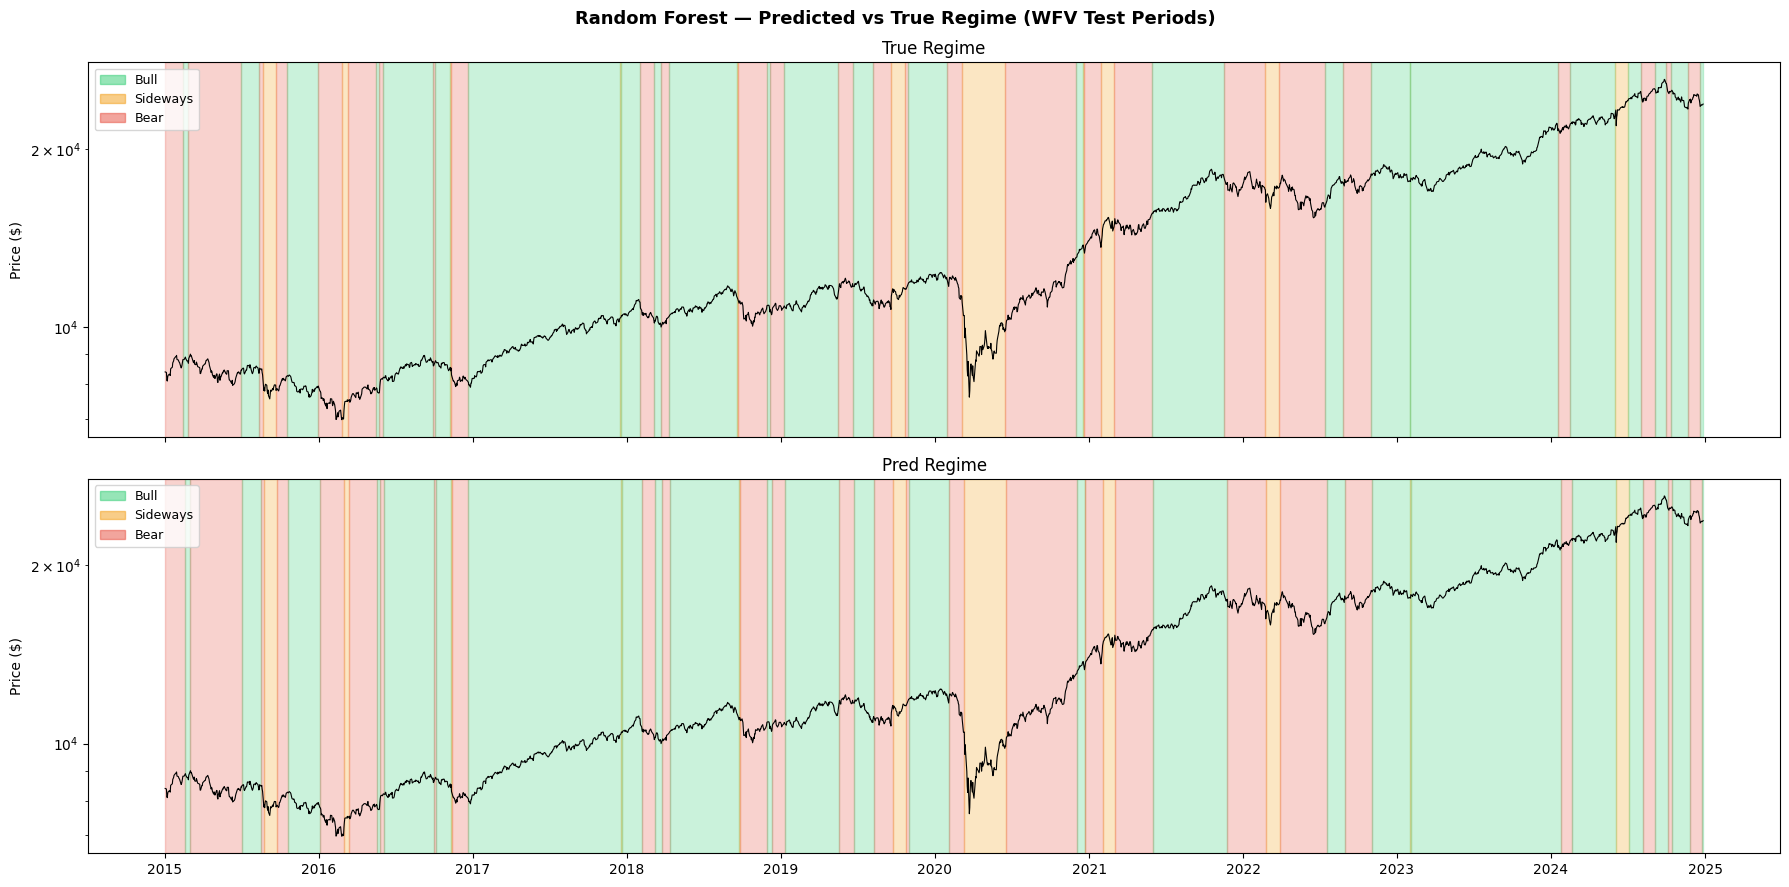

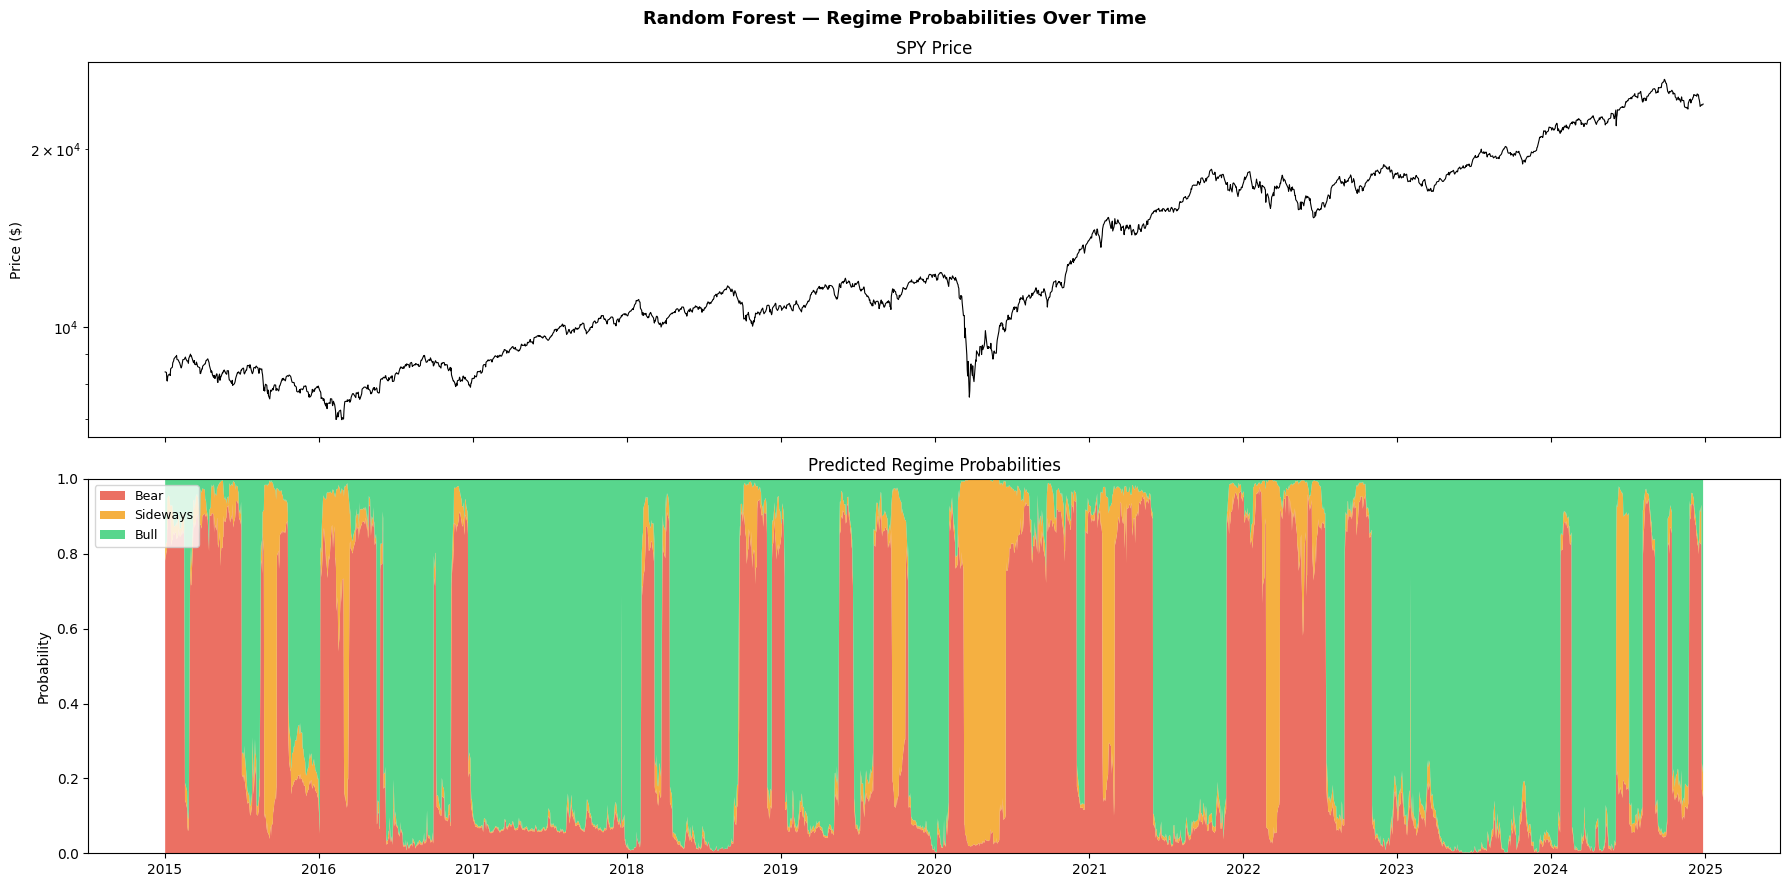

In [8]:
# Visualize RF predictions
fig = plot_predictions_vs_true(rf_preds, 'Random Forest')
fig.savefig('plots/08_rf_predictions.png', dpi=150, bbox_inches='tight')
plt.show()

fig2 = plot_probability_timeline(rf_preds, 'Random Forest')
if fig2:
    fig2.savefig('plots/09_rf_probabilities.png', dpi=150, bbox_inches='tight')
    plt.show()

In [22]:
print('=' * 60)
print('MODEL 3: XGBoost')
print('=' * 60)

# Class weights to handle imbalance (Bear class is rarer)
class_counts = df[TARGET_COL].value_counts().sort_index()
total = class_counts.sum()
class_weights = {k: total / (len(class_counts) * v) for k, v in class_counts.items()}
sample_weights = df[TARGET_COL].map(class_weights).values

xgb_params = {
    'n_estimators'      : 500,
    'max_depth'         : 5,
    'learning_rate'     : 0.05,
    'subsample'         : 0.8,
    'colsample_bytree'  : 0.8,
    'reg_alpha'         : 0.1,     # L1 regularization
    'reg_lambda'        : 1.0,     # L2 regularization
    'use_label_encoder' : False,
    'eval_metric'       : 'mlogloss',
    'random_state'      : RANDOM_SEED,
    'n_jobs'            : -1,
}

xgb_results, xgb_preds = wfv.run(
    model_factory=lambda: xgb.XGBClassifier(**xgb_params),
    model_name='XGBoost',
    scale=True   # XGBoost benefits slightly from scaling
)

print()
print('Aggregate (mean across folds):')
print(xgb_results.mean(numeric_only=True).round(4))

xgb_model = xgb.XGBClassifier(**xgb_params)
xgb_scaler = StandardScaler()
X_all_scaled = xgb_scaler.fit_transform(df[selected_features])
xgb_model.fit(X_all_scaled, df[TARGET_COL])

xgb_run_id = log_wfv_run(
    xgb_model, 'XGBoost', xgb_params,
    xgb_results, xgb_preds, selected_features
)

MODEL 3: XGBoost
  2015 | acc=0.926 | f1_macro=0.919 | f1_bear=0.935 | f1_bull=0.918 | trans_acc=0.000 | n_train=1,662
  2016 | acc=0.898 | f1_macro=0.838 | f1_bear=0.901 | f1_bull=0.908 | trans_acc=0.100 | n_train=1,906
  2017 | acc=0.996 | f1_macro=0.499 | f1_bear=0.000 | f1_bull=0.998 | trans_acc=0.500 | n_train=2,150
  2018 | acc=0.943 | f1_macro=0.628 | f1_bear=0.930 | f1_bull=0.954 | trans_acc=0.125 | n_train=2,398
  2019 | acc=0.942 | f1_macro=0.907 | f1_bear=0.892 | f1_bull=0.972 | trans_acc=0.571 | n_train=2,643
  2020 | acc=0.944 | f1_macro=0.929 | f1_bear=0.956 | f1_bull=0.868 | trans_acc=0.167 | n_train=2,884
  2021 | acc=0.960 | f1_macro=0.929 | f1_bear=0.955 | f1_bull=0.983 | trans_acc=0.000 | n_train=3,134
  2022 | acc=0.960 | f1_macro=0.944 | f1_bear=0.968 | f1_bull=0.959 | trans_acc=0.200 | n_train=3,382
  2023 | acc=0.992 | f1_macro=0.332 | f1_bear=0.000 | f1_bull=0.996 | trans_acc=0.500 | n_train=3,630
  2024 | acc=0.893 | f1_macro=0.864 | f1_bear=0.836 | f1_bull=0.9

2026/03/01 12:51:24 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


  MLflow run logged: 1623b412...


In [ ]:
fig = plot_predictions_vs_true(xgb_preds, 'XGBoost')
fig.savefig('plots/10_xgb_predictions.png', dpi=150, bbox_inches='tight')
plt.show()

fig2 = plot_probability_timeline(xgb_preds, 'XGBoost')
if fig2:
    fig2.savefig('plots/11_xgb_probabilities.png', dpi=150, bbox_inches='tight')
    plt.show()

In [23]:
print('=' * 60)
print('MODEL 4: LightGBM')
print('=' * 60)

lgb_params = {
    'n_estimators'       : 500,
    'max_depth'          : 6,
    'learning_rate'      : 0.05,
    'num_leaves'         : 31,
    'subsample'          : 0.8,
    'colsample_bytree'   : 0.8,
    'reg_alpha'          : 0.1,
    'reg_lambda'         : 1.0,
    'class_weight'       : 'balanced',
    'objective'          : 'multiclass',
    'num_class'          : 3,
    'random_state'       : RANDOM_SEED,
    'n_jobs'             : -1,
    'verbose'            : -1,
}

lgb_results, lgb_preds = wfv.run(
    model_factory=lambda: lgb.LGBMClassifier(**lgb_params),
    model_name='LightGBM',
    scale=True
)

print()
print('Aggregate (mean across folds):')
print(lgb_results.mean(numeric_only=True).round(4))

lgb_model = lgb.LGBMClassifier(**lgb_params)
lgb_scaler = StandardScaler()
X_all_lgb = lgb_scaler.fit_transform(df[selected_features])
lgb_model.fit(X_all_lgb, df[TARGET_COL])

lgb_run_id = log_wfv_run(
    lgb_model, 'LightGBM', lgb_params,
    lgb_results, lgb_preds, selected_features
)

MODEL 4: LightGBM
  2015 | acc=0.926 | f1_macro=0.919 | f1_bear=0.935 | f1_bull=0.918 | trans_acc=0.000 | n_train=1,662
  2016 | acc=0.906 | f1_macro=0.844 | f1_bear=0.908 | f1_bull=0.918 | trans_acc=0.100 | n_train=1,906
  2017 | acc=0.996 | f1_macro=0.499 | f1_bear=0.000 | f1_bull=0.998 | trans_acc=0.500 | n_train=2,150
  2018 | acc=0.943 | f1_macro=0.628 | f1_bear=0.930 | f1_bull=0.954 | trans_acc=0.125 | n_train=2,398
  2019 | acc=0.946 | f1_macro=0.928 | f1_bear=0.896 | f1_bull=0.969 | trans_acc=0.429 | n_train=2,643
  2020 | acc=0.948 | f1_macro=0.934 | f1_bear=0.959 | f1_bull=0.880 | trans_acc=0.167 | n_train=2,884
  2021 | acc=0.964 | f1_macro=0.940 | f1_bear=0.959 | f1_bull=0.983 | trans_acc=0.000 | n_train=3,134
  2022 | acc=0.956 | f1_macro=0.940 | f1_bear=0.964 | f1_bull=0.952 | trans_acc=0.200 | n_train=3,382
  2023 | acc=0.992 | f1_macro=0.332 | f1_bear=0.000 | f1_bull=0.996 | trans_acc=0.500 | n_train=3,630
  2024 | acc=0.885 | f1_macro=0.878 | f1_bear=0.818 | f1_bull=0.

2026/03/01 12:52:01 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/01 12:52:01 WARNING mlflow.lightgbm: Saving the models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


  MLflow run logged: d9352e7b...


In [24]:
# Aggregate comparison table
comparison = pd.DataFrame({
    'Naive Baseline' : baseline_results.mean(numeric_only=True),
    'Random Forest'  : rf_results.mean(numeric_only=True),
    'XGBoost'        : xgb_results.mean(numeric_only=True),
    'LightGBM'       : lgb_results.mean(numeric_only=True),
}).T

metric_cols = ['accuracy', 'f1_macro', 'f1_weighted', 'f1_bear', 'f1_sideways', 'f1_bull', 'transition_acc']
comparison = comparison[metric_cols].round(4)

print('=' * 80)
print('MODEL COMPARISON — Mean Across All WFV Folds')
print('=' * 80)
print(comparison.to_string())
print()

# Highlight best in each column
print('Best model per metric:')
for col in metric_cols:
    best = comparison[col].idxmax()
    print(f'  {col:<20}: {best} ({comparison.loc[best, col]:.4f})')

MODEL COMPARISON — Mean Across All WFV Folds
                accuracy  f1_macro  f1_weighted  f1_bear  f1_sideways  f1_bull  transition_acc
Naive Baseline    0.3601    0.1624       0.2331   0.4871       0.0000   0.0000          0.3629
Random Forest     0.9522    0.8057       0.9523   0.7451       0.6145   0.9580          0.1000
XGBoost           0.9453    0.7789       0.9449   0.7371       0.6014   0.9482          0.2363
LightGBM          0.9461    0.7842       0.9458   0.7369       0.6179   0.9479          0.2220

Best model per metric:
  accuracy            : Random Forest (0.9522)
  f1_macro            : Random Forest (0.8057)
  f1_weighted         : Random Forest (0.9523)
  f1_bear             : Random Forest (0.7451)
  f1_sideways         : LightGBM (0.6179)
  f1_bull             : Random Forest (0.9580)
  transition_acc      : Naive Baseline (0.3629)


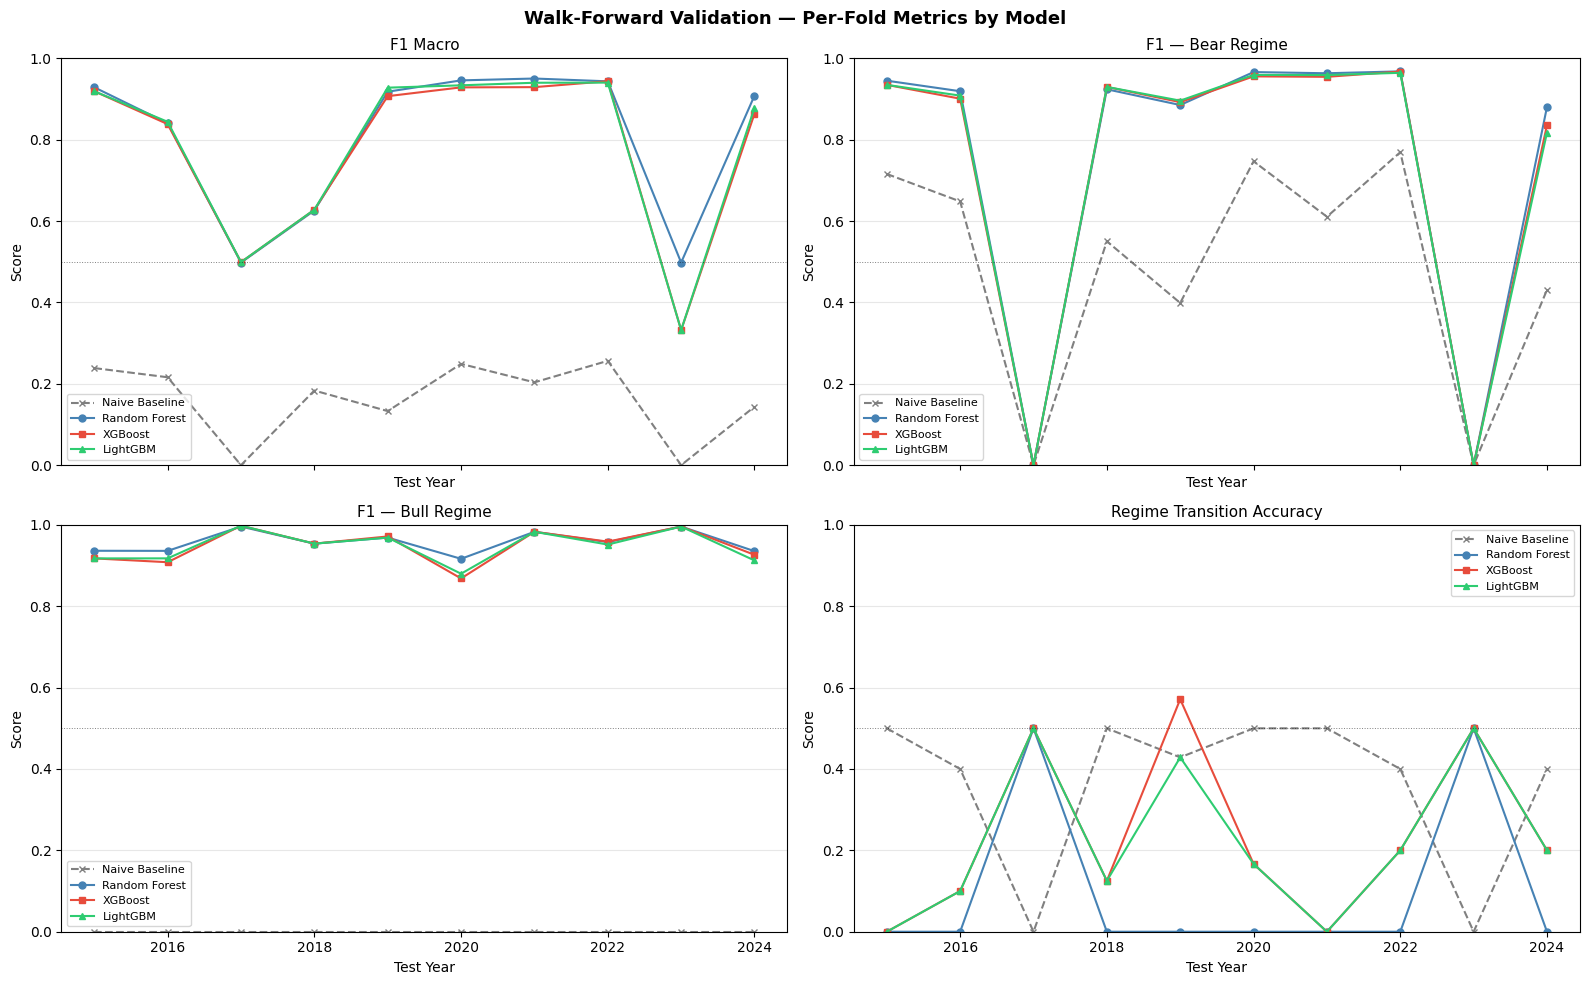

In [25]:
# Visual comparison: per-fold F1 across models
fig, axes = plt.subplots(2, 2, figsize=(16, 10), sharex=True)
fig.suptitle('Walk-Forward Validation — Per-Fold Metrics by Model', fontsize=13, fontweight='bold')

metrics_to_plot = [
    ('f1_macro',       'F1 Macro'),
    ('f1_bear',        'F1 — Bear Regime'),
    ('f1_bull',        'F1 — Bull Regime'),
    ('transition_acc', 'Regime Transition Accuracy'),
]

model_styles = {
    'Naive Baseline': ('gray',     '--',  'x'),
    'Random Forest' : ('steelblue', '-',  'o'),
    'XGBoost'       : ('#e74c3c',  '-',  's'),
    'LightGBM'      : ('#2ecc71',  '-',  '^'),
}

results_map = {
    'Naive Baseline': baseline_results,
    'Random Forest' : rf_results,
    'XGBoost'       : xgb_results,
    'LightGBM'      : lgb_results,
}

for ax, (metric, title) in zip(axes.flat, metrics_to_plot):
    for model_name, (color, ls, marker) in model_styles.items():
        res = results_map[model_name]
        ax.plot(res['fold'], res[metric], color=color, linestyle=ls,
                marker=marker, markersize=5, linewidth=1.5, label=model_name)
    ax.set_title(title, fontsize=11)
    ax.set_ylabel('Score')
    ax.set_xlabel('Test Year')
    ax.legend(fontsize=8)
    ax.set_ylim(0, 1)
    ax.axhline(0.5, color='black', linestyle=':', linewidth=0.7, alpha=0.5)
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('plots/12_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

In [26]:
# Detailed classification report for the best model (on all WFV test data combined)
best_model_name = comparison['f1_macro'].idxmax()
best_preds_map  = {
    'Random Forest' : rf_preds,
    'XGBoost'       : xgb_preds,
    'LightGBM'      : lgb_preds,
    'Naive Baseline': baseline_preds,
}
best_preds = best_preds_map[best_model_name]

print(f'Best model: {best_model_name}')
print()
print(classification_report(
    best_preds['y_true'],
    best_preds['y_pred'],
    target_names=['Bear', 'Sideways', 'Bull']
))

Best model: Random Forest

              precision    recall  f1-score   support

        Bear       0.94      0.94      0.94       886
    Sideways       0.90      0.90      0.90       183
        Bull       0.97      0.97      0.97      1388

    accuracy                           0.95      2457
   macro avg       0.93      0.93      0.93      2457
weighted avg       0.95      0.95      0.95      2457



In [27]:
# Determine best model by WFV F1 macro
model_map = {
    'Random Forest' : (rf_model,  None,       rf_params),
    'XGBoost'       : (xgb_model, xgb_scaler, xgb_params),
    'LightGBM'      : (lgb_model, lgb_scaler, lgb_params),
}

best_model_obj, best_scaler, best_params = model_map.get(
    best_model_name,
    model_map['XGBoost']   # fallback
)

# Package everything the API needs for inference
deployment_bundle = {
    'model'            : best_model_obj,
    'scaler'           : best_scaler,
    'feature_cols'     : selected_features,
    'model_name'       : best_model_name,
    'model_params'     : best_params,
    'wfv_f1_macro'     : float(comparison.loc[best_model_name, 'f1_macro']),
    'wfv_accuracy'     : float(comparison.loc[best_model_name, 'accuracy']),
    'regime_names'     : REGIME_NAMES,
    'trained_on'       : str(datetime.today().date()),
}

with open('models/best_model.pkl', 'wb') as f:
    pickle.dump(deployment_bundle, f)

# Also save comparison table
comparison.to_csv('data/model_comparison.csv')

print(f'✅ Best model saved: models/best_model.pkl')
print(f'   Model           : {best_model_name}')
print(f'   WFV F1 Macro    : {comparison.loc[best_model_name, "f1_macro"]:.4f}')
print(f'   WFV Accuracy    : {comparison.loc[best_model_name, "accuracy"]:.4f}')
print(f'   Features        : {len(selected_features)}')
print()
print('✅ Saved: data/model_comparison.csv')

✅ Best model saved: models/best_model.pkl
   Model           : Random Forest
   WFV F1 Macro    : 0.8057
   WFV Accuracy    : 0.9522
   Features        : 52

✅ Saved: data/model_comparison.csv
